# Comparison of lightcone noise samples between `tuesday` and `tools21cm`

In this demo, we compare lightcone noise generation methods from `tools21cm` (master branch on 01/07/25, commit c0cc4d5) with `tuesday`.
This will demonstrate some more of the parameters and concepts concerning the construction of "observed" lightcones with `tuesday`, as 
compared to the tutorial "Adding mock observational effects to lightcones", as well as showing compatibilty with the widely-used
`tools21cm` code for a specific set of choices.

Throughout this demo we will use the `AA4` SKA layout.

## Imports and Setup

We start by importing key modules and defining a plotting function to compare outputs from the two codes:

In [1]:
# Basic dependencies
import astropy.units as un
import matplotlib.pyplot as plt
import numpy as np

# 21cmSense interfaces used in tuesday
from py21cmsense import Observation, Observatory, convert_half_to_full_uv_plane
from py21cmsense.conversions import f2z

# tuesday functions -- import as "tues" so it's obvious throughout
# the demo where the functions are coming from.
from tuesday import core as tues

# Import tools21cm functions from the radio_telescope_noise
# module with name "tools"
from tools21cm import radio_telescope_noise  as tools


In [28]:
import tuesday
import tools21cm
print("Using tuesday version:", tuesday.__version__)
print("Using tools21cm version:", tools21cm.__version__)

Using tuesday version: 2.3.2.dev52+g39d6610e4.d20260607
Using tools21cm version: 2.3.10


In [2]:
def compare(
    tools_qt: np.ndarray,   # 2D array
    tuesday_qt: np.ndarray, # 2D array
    qt_name: str="", 
    f="150 MHz", 
    vmin=None, 
    vmax=None
):
    """Compare a tools21cm quantity to a tuesday quantity."""
    fig, axs = plt.subplots(
        1, 3, figsize=(12, 6), gridspec_kw={"width_ratios": [1, 1, 0.07]}
    )

    # Set the same vmin/vmax for the plot from each code.
    if vmin is None:
        vmin = np.nanpercentile(tools_qt, 2.5)
    if vmax is None:
        vmax = np.nanpercentile(tools_qt, 97.5)
        if np.isnan(vmax):
            vmax = np.nanmax(tools_qt)
            
    axs[0].set_title(f"tuesday - {qt_name} at {f} for SKA AA4")
    axs[0].imshow(np.flip(tuesday_qt.T), origin="lower", vmin=vmin, vmax=vmax)
    axs[1].set_title(f"tools21cm - {qt_name} at {f} for SKA AA4")
    im = axs[1].imshow(tools_qt.T, origin="lower", vmin=vmin, vmax=vmax, interpolation='none')

    fig.colorbar(im, label=qt_name, cax=axs[2], fraction=0.1, shrink=0.6)
    plt.show()
    err = tools_qt.T - np.flip(tuesday_qt.T)
    vmin = -np.nanpercentile(np.abs(err), 97.5)
    vmax = -vmin
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    im = axs[0].imshow(err, vmin=vmin, vmax=vmax, origin="lower",cmap='bwr')
    fig.colorbar(
        im,
        label=f"tools21cm  {qt_name} - 21cmSense {qt_name}",
        fraction=0.1,
        shrink=0.8,
    )
    axs[1].hist(err.ravel(), bins=np.linspace(vmin, vmax, 20))
    axs[1].set_xlabel(f"tools21cm {qt_name} - 21cmSense {qt_name}")
    plt.show()

## Specify observing and lightcone parameters

First we must set up the parameters of the "observation". For `tuesday`, this is achieved through the `21cmSense` interfaces `Observatory` and
`Observation`:

In [3]:
observatory = Observatory.from_ska("LOW_FULL_AA4")
observation = Observation(
    observatory=observatory,
    track = 2.0 * un.hour,
    time_per_day = 2.0 * un.hour,
    integration_time = 60 * un.s,        
    n_days=167,
    tsky_amplitude=60.0 * un.K,   # to be consistent with tools21cm
    tsky_ref_freq=300.0 * un.MHz,
    spectral_index=2.55,
)

freqs = np.array([150.0, 250.0]) * un.MHz

For `tools21cm` the array layout is generated through a specific SKA function:

In [4]:
enu_coords = tools.get_SKA_Low_layout("AA4", unit="enu")

AA4 contains 512 antennae.


Let's check that the array layout is the same between the codes:

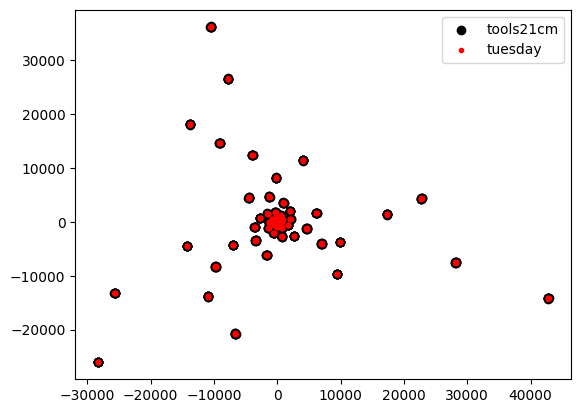

In [5]:
plt.scatter(enu_coords[:, 0], enu_coords[:, 1], color="k", label="tools21cm")
plt.scatter(
    observatory.antpos[:, 0],
    observatory.antpos[:, 1],
    color="r",
    marker=".",
    label="tuesday",
)
plt.legend()
plt.show()

We confirm that both `tools21cm` and `21cmSense` (and thus `tuesday`) are using the same SKA antenna layout.

Now we must also specify the dimensions of the "lightcone" in which we will generate our noise samples.

Note that the lightcone must have the last axis be the "redshift" or "frequency" axis.

In [6]:
lc_shape = (200, 200, len(freqs))
boxlength = 300.0 * un.Mpc

## Calculate UV Sampling

The fundamental computation that needs to happen to produce noise samples is to calculate a grid that specifies how many baselines sample
each Fourier mode over the course of the observation. We perform this calculation with each code.

Note that there are subtleties concerning how to specify the UV sampling on a lightcone that is chosen arbitrarily, without being tied directly
to an instrument. These subtleties are outlined in the API documentation of the `tuesday.core.noise` module. 

### With `tuesday`

In [7]:
ugrid_edges, vgrid_edges, uv_coverage = tues.compute_uv_sampling(
    observation=observation,
    freqs=freqs,
    box_length=boxlength,
    box_ncells = lc_shape[0]
)

finding redundancies: 130816ants [00:00, 133615.58ants/s]


### With `tools21cm`

In [8]:
redshifts = [f2z(freq) for freq in freqs]

#uvcov_tools = np.zeros(lc_shape)
uv_map_tools = np.zeros(lc_shape)

for i, z in enumerate(redshifts):
    uv_map_tools[...,i], Nant = tools.get_uv_map(
        lc_shape[0],
        z,
        boxsize=boxlength.value,
        int_time=observation.integration_time.to_value('s'),
        total_int_time=observation.track.to_value("hour"),
        include_mirror_baselines=True,
        declination=-26.824722,
    )
uvcov_tools = np.fft.fftshift(uv_map_tools, axes=(0,1)) * int(
    (observation.track / observation.integration_time)
)

AA4 contains 512 antennae.
ENU -> ECEF -> XYZ
Generating uv map from daily observations...


Gridding uv tracks: 100%|██████████| 120/120 [00:04<00:00, 26.33it/s]


...done
AA4 contains 512 antennae.
ENU -> ECEF -> XYZ
Generating uv map from daily observations...


Gridding uv tracks: 100%|██████████| 120/120 [00:04<00:00, 27.86it/s]

...done


### Compare UV Sampling

A key difference between `tuesday` and `tools21cm` is that the UV coverage in `tuesday` only covers half of the UV plane, since the 
other half is redundant. To properly compare here, we need to transform it:

In [9]:
full_uv_coverage = convert_half_to_full_uv_plane(uv_coverage)

Another difference between the two codes is that `tools21cm` places `u=0` directly at the center of the UV bins. However,
when considering the FFT, the zero mode should be placed at the center of bin ``n//2``, which is what `21cmSense` does.
In the case that `n` is even, this results in `tools21cm` having zero at the *edge* of two bins, and therefore will not quite 
match up with `tuesday`. When `n` is odd, they *should* match up, but in fact `tools21cm` seems to have symmetry in the first
`n-2` bins, with extra values in the last two bins. This is probably a bug.

`tuesday` on the other hand satisfies the requirements of the 2D FFT (that the Nyquist frequency sample is the most negative, and does not have a matching positive sample):

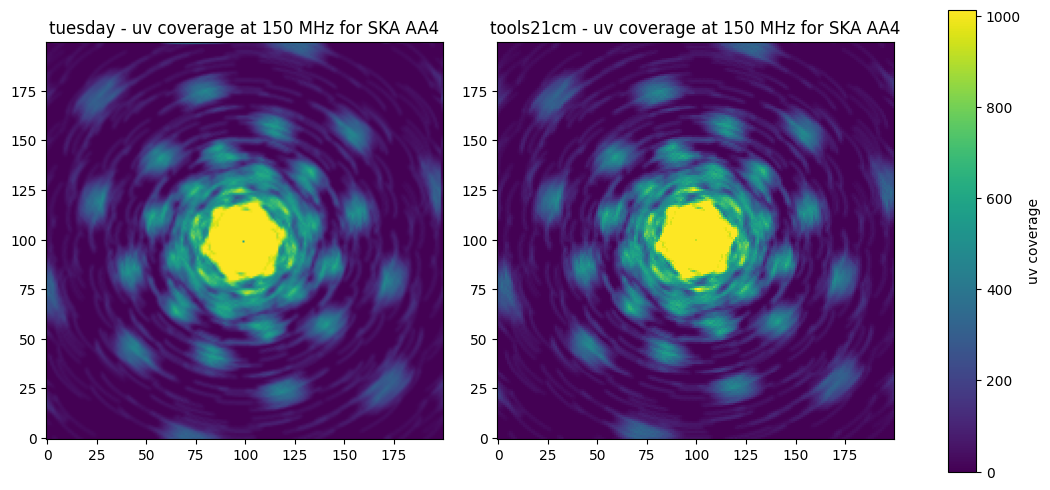

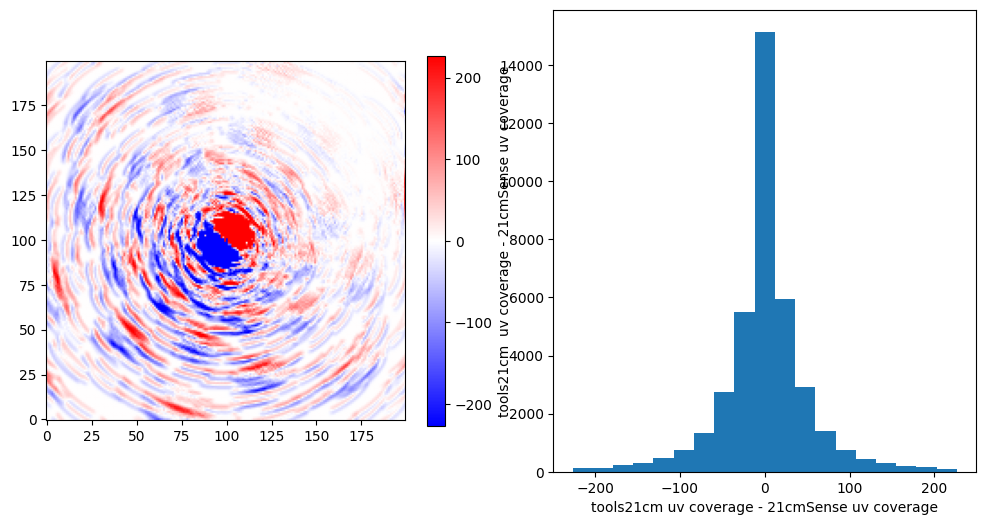

In [10]:
compare(uvcov_tools[..., 0], full_uv_coverage[..., 0]/2, "uv coverage", f="150 MHz")

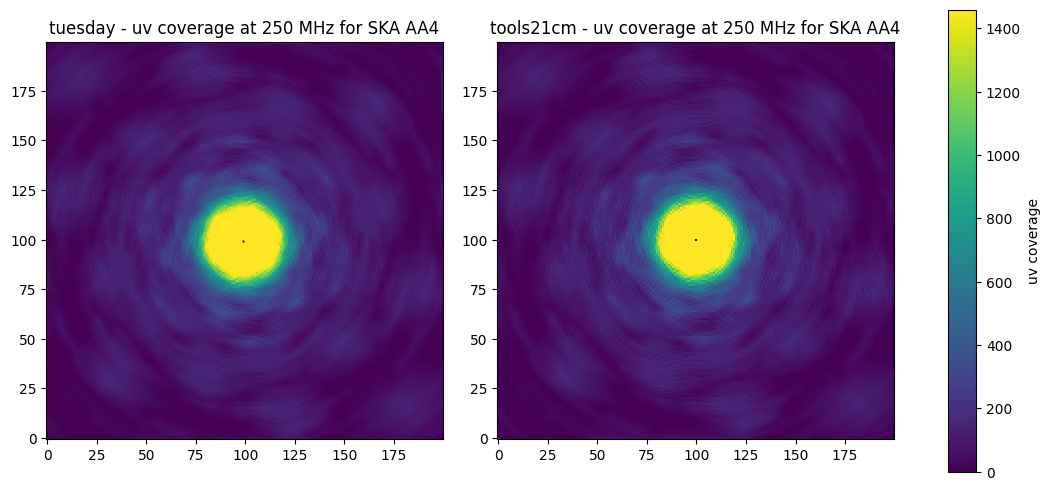

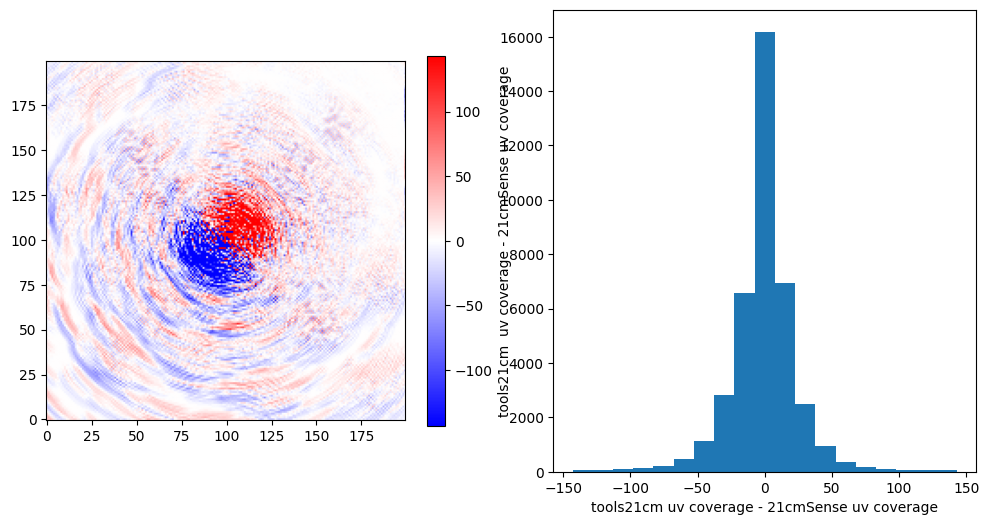

In [11]:
compare(uvcov_tools[..., 1], full_uv_coverage[..., 1]/2, "uv coverage", f="250 MHz")

The lower-left panels here show clearly this slight difference between the UV grid specification in both codes

## Calculate Thermal RMS on UV Grid

### With `tuesday`

Note that we're specifying `antenna_effective_area` here specifically to get a closer answer to `tools21cm` which 
uses these values. Furthermore, `min_nbls_per_uv_cell` is set here because in `tools21cm`, for the final noise
calculation, all cells with a UV sampling of less than 0.1 are *hard-coded* to be ignored. However that UV sampling
is normalized by the number of integrations in a track. This comes out to be 120, so we ignore cells with less
than 12 baseline-times.

In [12]:
sigma_uv_tues = tues.compute_thermal_rms_uvgrid(
    observation=observation,
    uv_coverage=uv_coverage,
    freqs=freqs,
    box_length=boxlength,
    box_slice_depth = 50*un.kHz,
    antenna_effective_area=[517.7, 186.4] * un.m**2,
    min_nbls_per_uv_cell=int(observation.track/observation.integration_time) / 10,
)

### With tools21cm

In [13]:
from tools21cm.radio_telescope_sensitivity import (
    jansky_2_kelvin,
    sigma_noise_radio,
)

In [14]:
sigma_tools = np.zeros(len(freqs))
sigma_uv_tools = np.zeros(lc_shape)

for i, freq in enumerate(freqs):
    sigma, rms_noi = sigma_noise_radio(
        f2z(freq),
        depth_mhz = 0.05,  # 50 kHz, like for tuesday
        obs_time = observation.n_days * observation.time_per_day.to_value('hour'),
        int_time = observation.integration_time.to_value("s"),
        uv_map=uvcov_tools,
        N_ant=512,
    )  # μJy

    sigma_tools[i] = jansky_2_kelvin(
        rms_noi, 
        z=f2z(freq), 
        boxsize=boxlength.to_value("Mpc"), 
        ncells=lc_shape[0]
    )  # mK
    
    sigma_uv_tools[..., i] = sigma_tools[i] / np.sqrt(uvcov_tools[..., i] * observation.n_days)
sigma_uv_tools[uvcov_tools < 0.1 * observation.track/observation.integration_time] = np.nan


Expected: rms in image in µJy per beam for full = 14.705732788379228
Effective baseline = 1.343464074485482 m
Calculated: rms in the visibility = 752949.6948973185 µJy

Expected: rms in image in µJy per beam for full = 17.689912566447656
Effective baseline = 1.6160882531873482 m
Calculated: rms in the visibility = 905742.9820969163 µJy


### Compare the thermal RMS noise

In [15]:
full_sigma_uv_tues = np.sqrt(convert_half_to_full_uv_plane(sigma_uv_tues**2, inverse_counts=True))

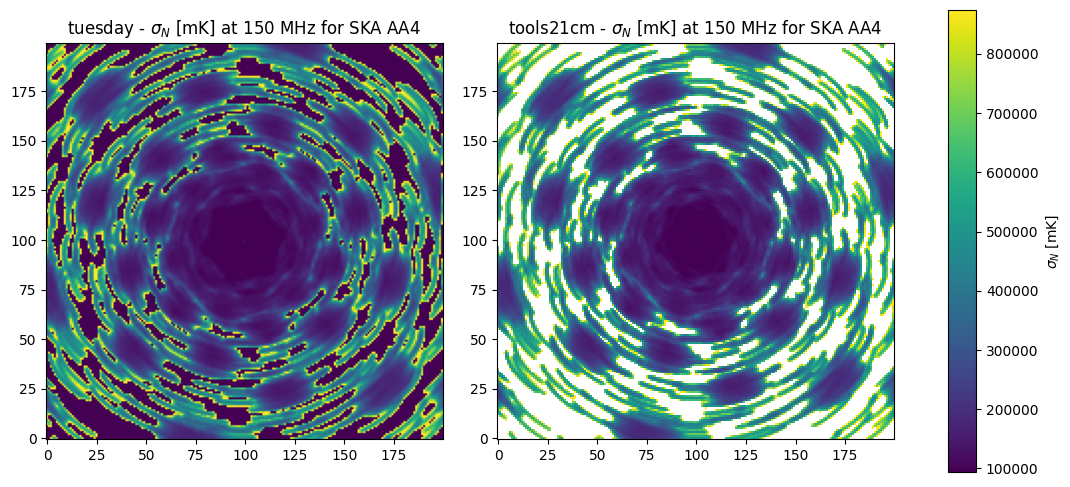

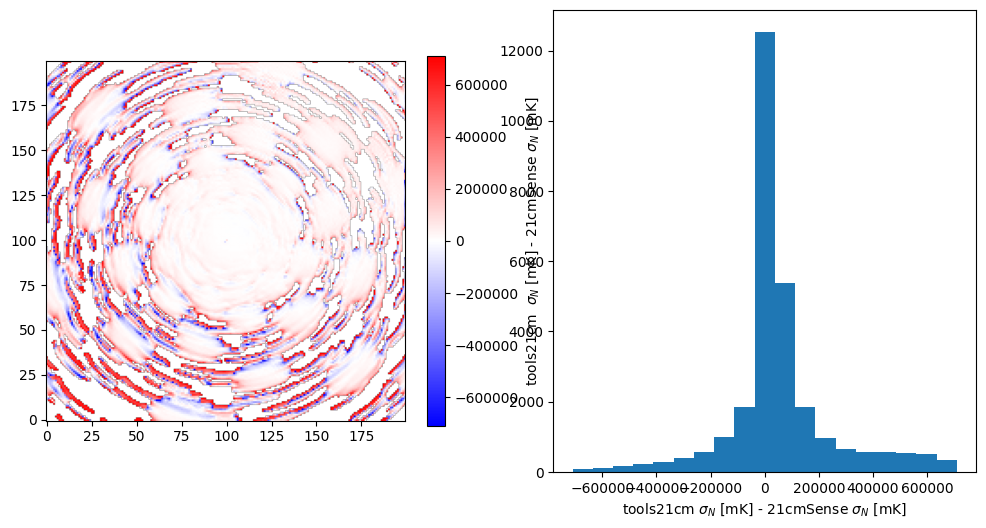

In [16]:
compare(sigma_uv_tools[..., 0], full_sigma_uv_tues[..., 0], r"$\sigma_{N}$ [mK]")

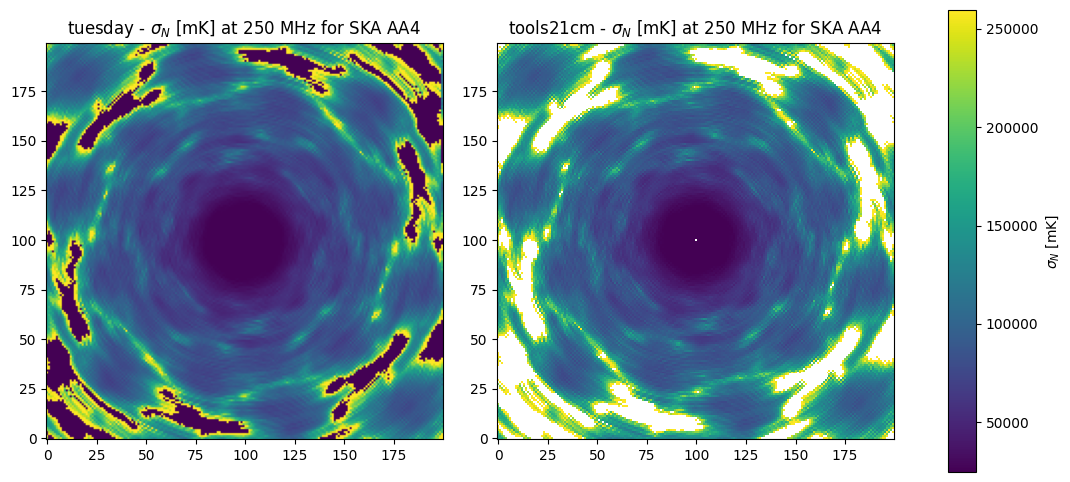

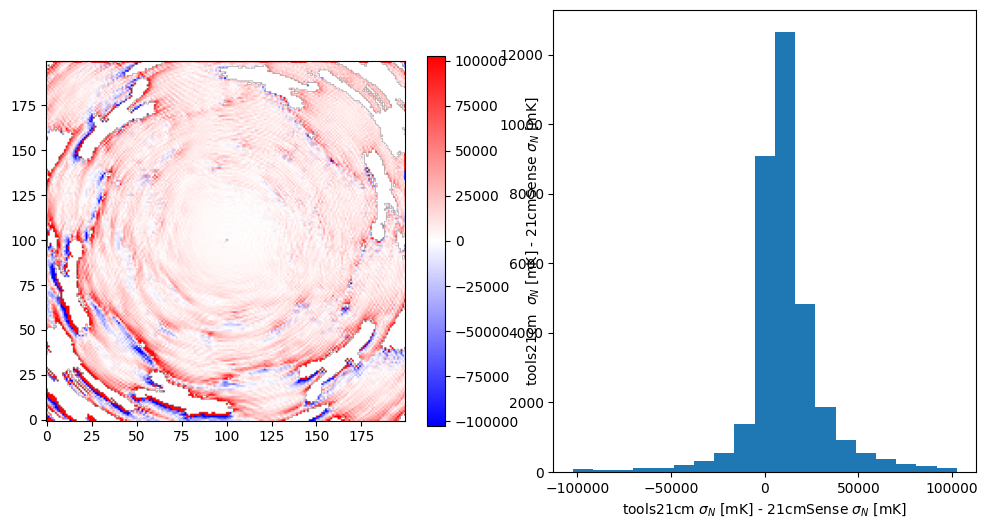

In [17]:
compare(sigma_uv_tools[..., 1], full_sigma_uv_tues[..., 1], r"$\sigma_{N}$ [mK]", f="250 MHz")

## Sample lightcone noise
The final step is to generate lightcone noise samples.

### With `tuesday`

With `tuesday` we can control the random generation by setting a random seed manually for reproducibility. If not set, a seed is chosen at random.\
We also set a spatial taper which is applied to the noise in UV space, before transforming to image space. While it is possible to do this,
it is not generally advised (and it is not default) unless you know that your lightcone is non-periodic (or are attempting to match
an observation where this same window has been applied). 

Since `tools21cm` hard-codes a Blackman-Harris spatial taper, we do the same here to ease comparison.

In [18]:
noise = tues.sample_from_rms_uvgrid(sigma_uv_tues, seed=4, spatial_taper='blackmanharris')

### With `tools21cm`

In [19]:
noise_tools = np.zeros_like(sigma_uv_tools)
for i, freq in enumerate(freqs):
    n = tools.noise_map(
        lc_shape[0],
        z=f2z(freq),
        depth_mhz=0.050,
        uv_map=uv_map_tools[...,i],
        obs_time=observation.n_days * observation.time_per_day.to_value("hour"),
        subarray_type="AA4",
        boxsize=boxlength.to_value("Mpc"),
        total_int_time=observation.time_per_day.to_value("hour"),
        int_time=observation.integration_time.to_value("s"),
    )
    
    noise_tools[..., i] = jansky_2_kelvin(
        n, f2z(freq), boxsize=boxlength.to_value("Mpc"), ncells=lc_shape[0]
    )

AA4 contains 512 antennae.
ENU -> ECEF -> XYZ
AA4 contains 512 antennae.
ENU -> ECEF -> XYZ


### Compare noise realisations

Note that `tools21cm` does something wrong in computing the noise: it does not impose the hermitian symmetry of the noise in the UV plane. This may account for some of the small differences still seen.

In [20]:
print("RMS in Image Space Tuesday: ", np.sqrt(np.mean(np.square(noise[0, ..., 0]))))
print("RMS in Image Space Tools: ", np.sqrt(np.mean(np.square(noise_tools[0, ..., 0]))))

RMS in Image Space Tuesday:  312.39737008319383 mK
RMS in Image Space Tools:  301.56519575376115


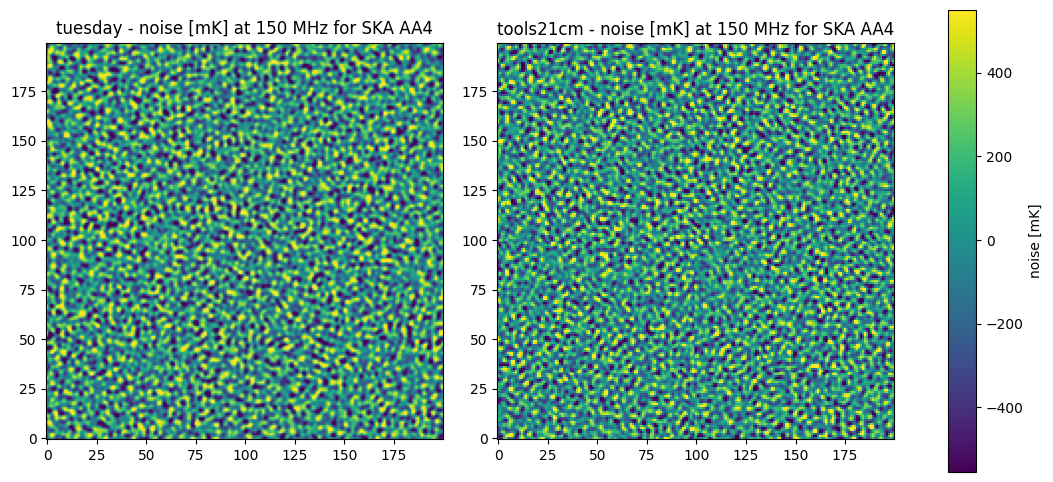

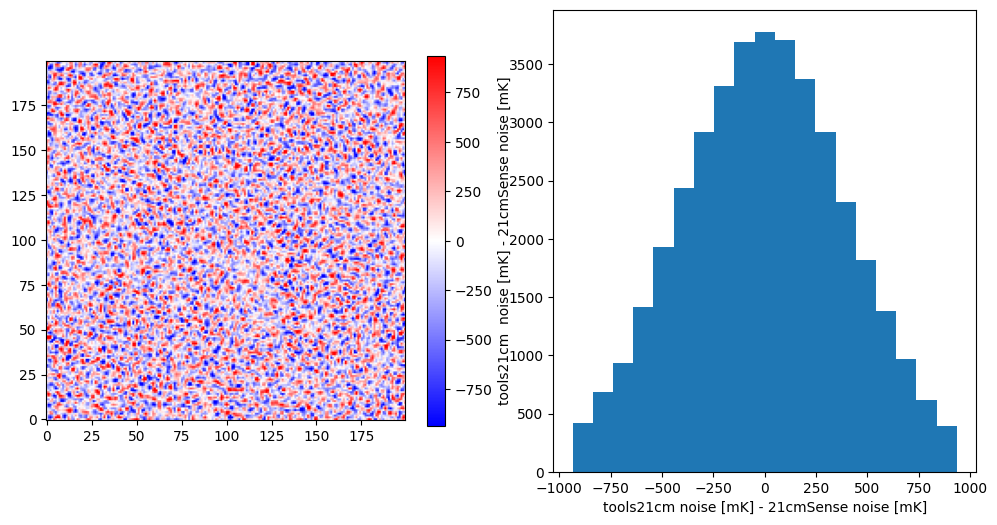

In [21]:
compare(noise_tools[..., 0], noise[0, ..., 0].value, "noise [mK]")

In [22]:
print("RMS in Image Space Tuesday: ", np.sqrt(np.mean(np.square(noise[0, ..., 1]))))
print("RMS in Image Space Tools: ", np.sqrt(np.mean(np.square(noise_tools[0, ..., 1]))))

RMS in Image Space Tuesday:  85.18307280936082 mK
RMS in Image Space Tools:  69.31508440976259


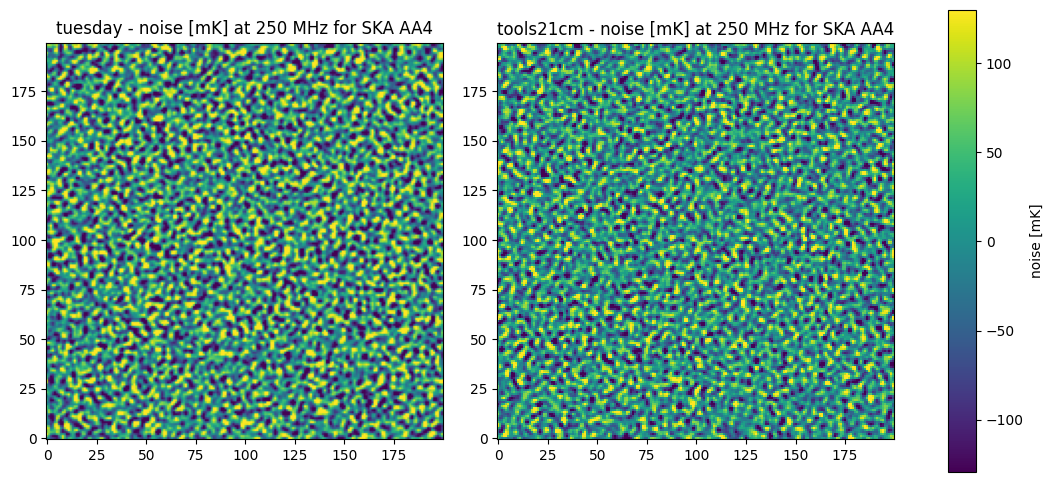

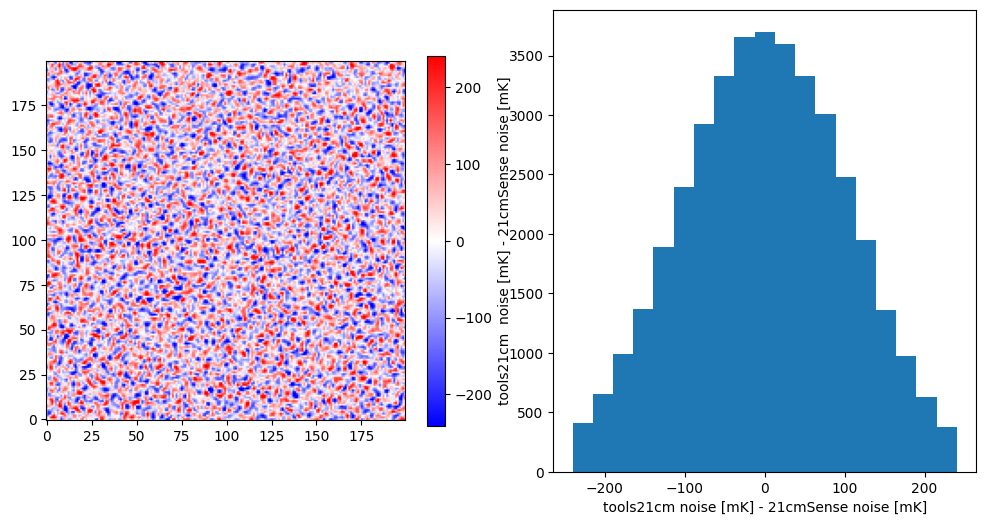

In [23]:
compare(noise_tools[..., 1], noise[0, ..., 1].value, "noise [mK]", f="250 MHz")

### Compare Power Spectra

In [24]:
from powerbox import get_power

In [25]:
ptues, k, *_ = get_power(noise[0, ..., 0].value, boxlength=boxlength.value)

In [26]:
ptool, k, *_ = get_power(noise_tools[0, ..., 0], boxlength=boxlength.value)

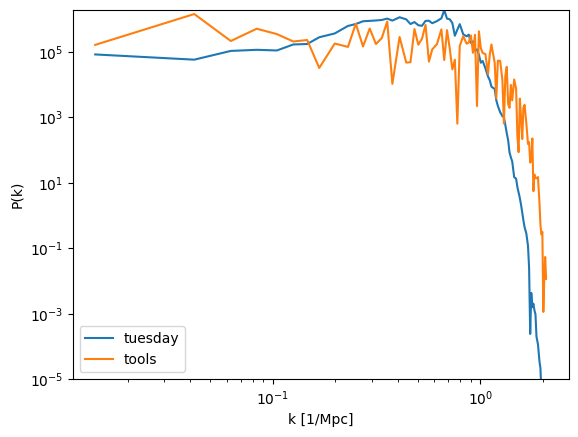

In [27]:
plt.plot(k, ptues, label='tuesday')
plt.plot(k, ptool, label='tools')

plt.ylim(1e-5,)
plt.yscale('log')
plt.legend()
plt.xlabel("k [1/Mpc]")
plt.ylabel("P(k)")
plt.xscale('log')